# XGBoost for Prediction of Tree Type

## Imports

### Modules

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
import sklearn
import seaborn as sns
from matplotlib import pyplot as plt

### Data

In [12]:
df = pd.read_parquet('GlobalGeoTree-6M\GlobalGeoTreeNoMissing.parquet')
df.head()

numeric_cols = df.select_dtypes(include=["number"]).columns
df = df.copy()
df[numeric_cols] = df[numeric_cols].astype(np.float32)

df = df.sample(int(1e6))

df.head()

<>:1: SyntaxWarning: invalid escape sequence '\G'
<>:1: SyntaxWarning: invalid escape sequence '\G'
C:\Users\yy21473\AppData\Local\Temp\ipykernel_18296\998067995.py:1: SyntaxWarning: invalid escape sequence '\G'
  df = pd.read_parquet('GlobalGeoTree-6M\GlobalGeoTreeNoMissing.parquet')


,sample_id,longitude,latitude,elevation,slope,aspect,soil_moisture_0_5cm,soil_moisture_5_15cm,soil_moisture_15_30cm,bio01,...,bio14,bio15,bio16,bio17,bio18,bio19,level0,level1_family,level2_genus,level3_species
160360,378628.0,120.877518,24.176840,619.0,25.0,113.0,249.0,248.0,249.0,200.0,...,19.0,83.0,1378.0,90.0,1378.0,171.0,Evergreen Broadleaf,Euphorbiaceae,Macaranga,Macaranga kilimanjarica
3147009,5362995.0,150.594864,-33.663662,345.0,7.0,90.0,77.0,77.0,77.0,153.0,...,50.0,38.0,458.0,162.0,425.0,200.0,Evergreen Broadleaf,Ericaceae,Styphelia,Styphelia fletcheri
5010062,4369559.0,-76.955437,39.164639,145.0,8.0,352.0,219.0,229.0,214.0,122.0,...,74.0,10.0,305.0,238.0,296.0,238.0,Deciduous Broadleaf,Sapindaceae,Acer,Acer rubrum
1271579,1830415.0,11.286355,46.330982,306.0,14.0,274.0,94.0,91.0,91.0,113.0,...,36.0,30.0,273.0,119.0,273.0,119.0,Deciduous Broadleaf,Plantaginaceae,Veronica,Veronica arvensis
183555,402800.0,121.311569,24.353500,1726.0,8.0,148.0,233.0,235.0,232.0,132.0,...,96.0,39.0,988.0,321.0,988.0,344.0,Evergreen Broadleaf,Pentaphylacaceae,Cleyera,Cleyera theoides


In [3]:

df.shape

(100000, 32)

## Set Predictors and Target Variables

In [4]:
predVaraibles = ['longitude', 'latitude', 'elevation', 'slope', 'aspect', 'soil_moisture_5_15cm', 'bio01', 'bio02', 'bio04', 'bio07', 'bio12', 'bio13', 'bio14', 'bio15']

targetVariable = ['level0']

df[targetVariable].astype('category')

dfX = df[predVaraibles]
dfY = df[targetVariable]

XTrain, XTest, YTrain, YTest = sklearn.model_selection.train_test_split(dfX, dfY, test_size=0.2)

### Pairs plot of non geographic variables

- far less interdependencies now, reducing multicollinearity

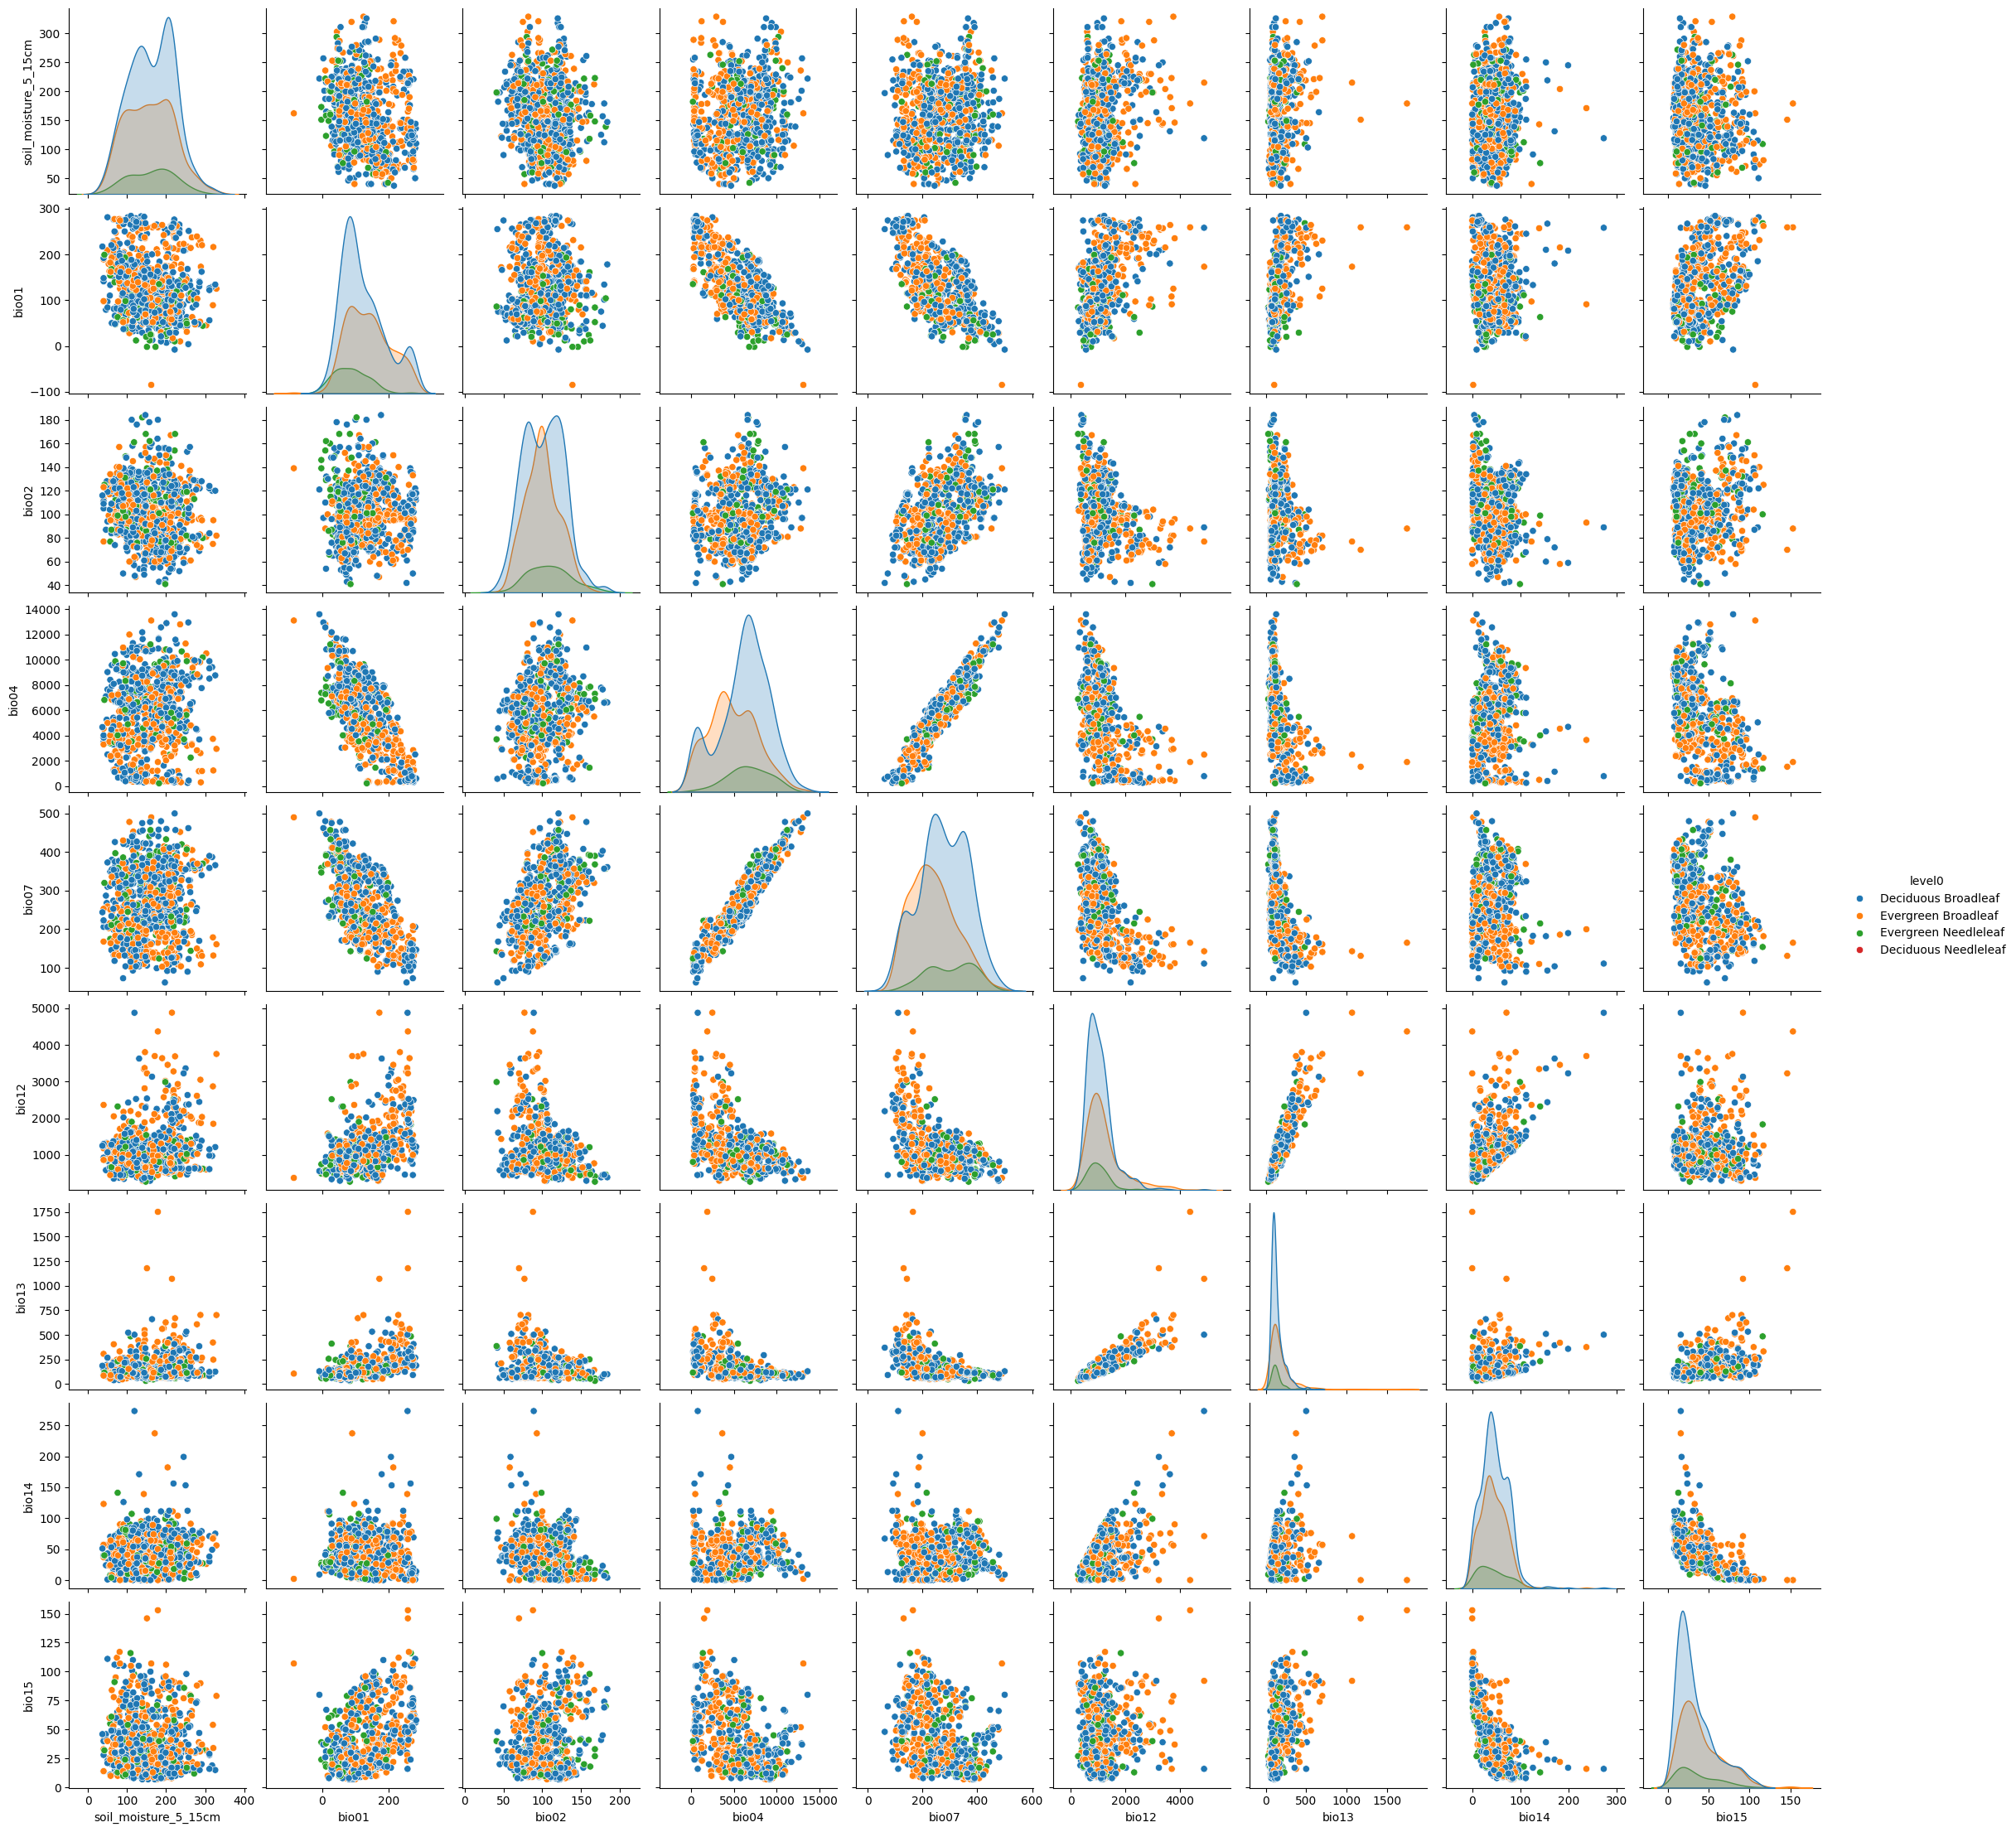

In [11]:
#allVars = predVaraibles.append(targetVariable[0])

varsToPlot = ['soil_moisture_5_15cm', 'bio01', 'bio02', 'bio04', 'bio07', 'bio12', 'bio13', 'bio14', 'bio15', 'level0']

dfSample = df[varsToPlot].sample(1000)


sns.pairplot(data = dfSample, hue = 'level0')

In [10]:
type(dfSample['level0'])

pandas.core.series.Series

## Define XGBoost Model

### Training

In [13]:
labelEncoder = sklearn.preprocessing.LabelEncoder()
YTrainEnc = labelEncoder.fit_transform(YTrain)

model = xgb.XGBClassifier(device = 'cuda:0', 
                          enable_categorical = True, 
                          tree_method = 'hist', 
                          subsample = 0.8, 
                          sampling_method = 'gradient_based', 
                          max_depth = 6, 
                          max_bin = 512, 
                          n_estimators = 250,
                          num_class = np.max(YTrainEnc))

model.fit(XTrain, YTrainEnc)

c:\Users\yy21473\.GitHubFiles\dst-group-work\GlobalGeoTree\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,'cuda:0'
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


### Testing

In [14]:
predEnc = model.predict(XTest)
pred = labelEncoder.inverse_transform(predEnc)

accuracy = sklearn.metrics.accuracy_score(YTest, pred)
print(accuracy)

#print(YTest)
#print(pred)

#print(YTest['level0'].unique().shape)


0.68455


c:\Users\yy21473\.GitHubFiles\dst-group-work\GlobalGeoTree\.venv\Lib\site-packages\xgboost\core.py:774: UserWarning: [13:41:04] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


### Confusion Matrix

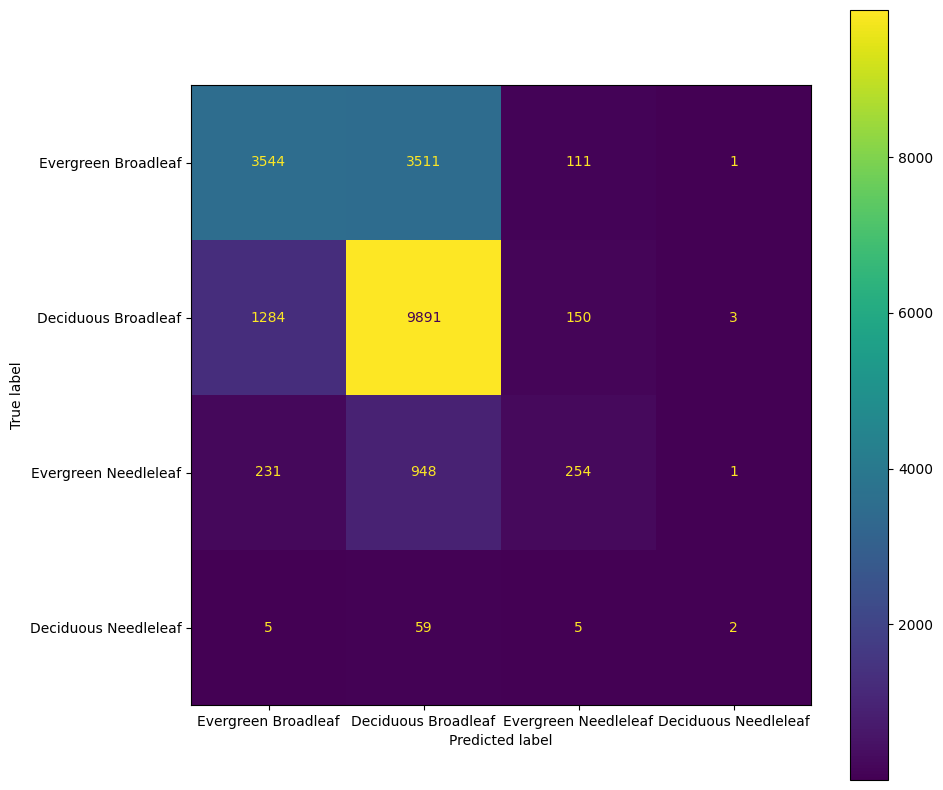

In [17]:
classNames = df['level0'].unique().tolist()
cm = sklearn.metrics.confusion_matrix(YTest, pred, labels =classNames)

figCM, axCM = plt.subplots(figsize = (10,10))

sklearn.metrics.ConfusionMatrixDisplay(cm, display_labels=classNames).plot(ax = axCM)

#for text in axCM.texts:
#    text.set_visible(False)